# Se importan las librerias

In [54]:
import pandas as pd                                    # pandas maneja las tablas (DataFrames), es el corazón del análisis
import numpy as np                                     # numpy hace las cuentas con vectores: logaritmos, promedios, simulaciones
import matplotlib.pyplot as plt                        # matplotlib es el que dibuja todas las gráficas
import seaborn as sns                                  # seaborn dibuja boxplots y heatmaps bonitos con una sola línea
from scipy import stats                                # scipy.stats trae Shapiro, Levene, t-test, chi2 y f_oneway (Casos 6 y 7)
import statsmodels.api as sm                           # statsmodels da la regresión OLS con tabla completa (Caso 8)
import statsmodels.formula.api as smf                  # la interfaz de fórmulas 'y ~ x' para el ANOVA de dos factores (Caso 7)
import statsmodels.stats.api as sms                    # de acá sale la prueba de Breusch-Pagan para heterocedasticidad (Caso 8)
from statsmodels.stats.stattools import jarque_bera    # Jarque-Bera revisa si los residuos son normales (Caso 8)
import warnings      
from scipy.stats import norm                                  # warnings controla los avisos que imprime Python
 


# Importando los datos

In [55]:
arriendos = pd.read_csv('base_arriendos.csv')

In [56]:
print("filas y columnas", arriendos.shape)
print("columnas", arriendos.columns)
print("tipos de datos", arriendos.dtypes)
arriendos.head(10)

filas y columnas (10001, 12)
columnas Index(['Rent Price', 'Area (sqm)', 'Area Const (sqm)', 'Bedrooms', 'Bathrooms',
       'Garages', 'Admon', 'estrato', 'antiguedad', 'zone', 'lon', 'lat'],
      dtype='str')
tipos de datos Rent Price            int64
Area (sqm)          float64
Area Const (sqm)    float64
Bedrooms            float64
Bathrooms               str
Garages             float64
Admon               float64
estrato             float64
antiguedad              str
zone                    str
lon                 float64
lat                 float64
dtype: object


,Rent Price,Area (sqm),Area Const (sqm),Bedrooms,Bathrooms,Garages,Admon,estrato,antiguedad,zone,lon,lat
0,2700000,67.33,67.33,3.0,2,1.0,298200.0,4.0,Entre 0 y 5 años,Occidental,-74.124664,4.656461
1,5710000,235.00,235.00,4.0,5,3.0,790000.0,6.0,Entre 5 y 10 años,Guaymaral,-74.059170,4.795217
2,2650000,120.00,120.00,5.0,2,2.0,NaN,3.0,Más de 20 años,Occidental,-74.090000,4.689000
3,10000000,420.00,420.00,4.0,5,4.0,960000.0,5.0,Entre 10 y 20 años,Noroccidente,-74.059950,4.763854
4,20000000,320.00,320.00,3.0,5,3.0,3750000.0,6.0,Entre 10 y 20 años,Norte,-74.047290,4.660591
5,6500000,200.00,200.00,4.0,5,3.0,1318000.0,6.0,Entre 0 y 5 años,Norte,-74.028900,4.744148
6,16900000,280.00,280.00,3.0,5,3.0,1700000.0,6.0,Más de 20 años,NaN,0.000000,0.000000
7,7642000,121.78,135.00,3.0,3,2.0,858000.0,4.0,Entre 10 y 20 años,Chapinero,-74.055870,4.650520
8,16000000,251.00,270.00,4.0,5,3.0,2900100.0,6.0,Entre 10 y 20 años,Norte,-74.052110,4.661777
9,17500000,500.00,500.00,4.0,5,4.0,641000.0,6.0,Entre 5 y 10 años,Norte,-74.034294,4.687253


In [57]:
# print("Conteo de baños", arriendos['Bathrooms'].value_counts(dropna=False))

nulos = arriendos.isna().sum()

# print("Cantidad de valores nulos en la columna Bathrooms:", nulos)
    
porcentaje = (nulos / len(arriendos)* 100).round(2)
#print("Porcentaje de valores nulos en la columna Bathrooms:", porcentaje, "%")



In [58]:
tabla_nulos = pd.DataFrame({'Nulos':nulos, 'Porcentaje':porcentaje})

tabla_nulos.sort_values('Nulos', ascending=False)

,Nulos,Porcentaje
Admon,1919,19.19
zone,497,4.97
lat,56,0.56
lon,56,0.56
antiguedad,13,0.13
estrato,5,0.05
Area (sqm),2,0.02
Area Const (sqm),1,0.01
Bathrooms,1,0.01
Bedrooms,1,0.01


In [59]:
arriendos.describe()

,Rent Price,Area (sqm),Area Const (sqm),Bedrooms,Garages,Admon,estrato,lon,lat
count,1.000100e+04,9999.000000,1.000000e+04,10000.000000,10000.00000,8.082000e+03,9996.000000,9945.000000,9945.000000
mean,2.131714e+07,253.242746,3.512579e+02,2.716700,1.97490,2.161207e+06,5.159264,-72.448449,4.582958
std,3.385278e+08,4805.112029,1.210210e+04,1.135064,1.24933,5.118971e+07,1.128132,10.795553,0.684238
min,0.000000e+00,1.000000,0.000000e+00,1.000000,0.00000,0.000000e+00,1.000000,-74.212140,0.000000
25%,3.087000e+06,70.000000,7.023250e+01,2.000000,1.00000,1.000000e+05,4.000000,-74.061104,4.661280
50%,6.416000e+06,144.000000,1.460000e+02,3.000000,2.00000,6.880000e+05,6.000000,-74.050900,4.678556
75%,1.100000e+07,261.000000,2.620000e+02,3.000000,3.00000,1.400000e+06,6.000000,-74.043160,4.703337
max,1.800000e+10,480000.000000,1.111150e+06,5.000000,4.00000,3.500000e+09,6.000000,0.000000,5.026003


In [60]:
base=arriendos.copy()
base = base.rename(columns={'Bathrooms':'Banos', 'Bedrooms':'Habitaciones', 
                            'Rent Price':'Precio', 'Area (sqm)':'Area', 'Area Const (sqm)':'Area_Const', 
                            'Garages':'Garages','Admon':'Admin','zone':'Zona'})

print(base.columns)

base['Banos'] = base['Banos'].str.replace('+', '',regex=False)
base['Banos'] = pd.to_numeric(base['Banos'], errors='coerce')

base.dtypes


Index(['Precio', 'Area', 'Area_Const', 'Habitaciones', 'Banos', 'Garages',
       'Admin', 'estrato', 'antiguedad', 'Zona', 'lon', 'lat'],
      dtype='str')


Precio            int64
Area            float64
Area_Const      float64
Habitaciones    float64
Banos           float64
Garages         float64
Admin           float64
estrato         float64
antiguedad          str
Zona                str
lon             float64
lat             float64
dtype: object

In [61]:
errores_coordenadas = ((base['lon'] == 0) | (base['lat'] == 0 ) ).sum()

print(errores_coordenadas)

base.loc[base['lon'] == 0, 'lon'] = np.nan
base.loc[base['lat'] == 0, 'lat'] = np.nan



print("Cantidad de valores nulos en la columna lon:", base['lon'].isna().sum())
print("Cantidad de valores nulos en la columna lat:", base['lat'].isna().sum())

216
Cantidad de valores nulos en la columna lon: 272
Cantidad de valores nulos en la columna lat: 272


In [62]:
filas_antes = len(base)
claves = ['Precio','Area','estrato','Zona','antiguedad','Habitaciones','Banos','Garages']
base = base.dropna(subset=claves)
filas_despues = len(base)

print("Cantidad de filas antes de eliminar los nulos:", filas_antes)
print("Cantidad de filas después de eliminar los nulos:", filas_despues)
print("Cantidad de filas eliminadas:", filas_antes - filas_despues)

Cantidad de filas antes de eliminar los nulos: 10001
Cantidad de filas después de eliminar los nulos: 9485
Cantidad de filas eliminadas: 516


In [63]:
n0 =len(base)
mask_precio = (base['Precio'] >=  400000 ) & (base['Precio'] <= 60000000 )
base = base[mask_precio]

print(n0 - len(base), "filas eliminadas por precio")


53 filas eliminadas por precio


In [65]:
n1 = len(base)                                                     # nuevo punto de partida para el siguiente filtro
mask_area = (base['Area'] >= 20) & (base['Area'] <= 1000)          # menos de 20 m2 no es una vivienda y más de 1000 m2 ya es una finca o un error de digitación
base = base[mask_area]                                             # aplico la segunda máscara
print(f"👉 Tras filtrar área:   {len(base):,} filas  (se fueron {n1 - len(base):,})")   # el efecto de este otro filtro

👉 Tras filtrar área:   9,304 filas  (se fueron 128)


In [67]:
base['Precio_por_mt2'] = base['Precio'] / base['Area']

quantiles = base['Precio_por_mt2'].quantile([0.25, 0.5, 0.75])
print(quantiles)

iqr = quantiles[0.75] - quantiles[0.25]
print("IQR:", iqr)

limite_inferior = quantiles[0.25] - 1.5 * iqr
limite_superior = quantiles[0.75] + 1.5 * iqr
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)


n2=len(base)
base =  base[(base['Precio_por_mt2'] >= limite_inferior) & (base['Precio_por_mt2'] <= limite_superior)]

print("Cantidad de registros antes del filtrado:", n2)
print("Cantidad de registros después del filtrado:", len(base))

print(quantiles)

0.25    32142.857143
0.50    43922.651934
0.75    56402.439024
Name: Precio_por_mt2, dtype: float64
IQR: 24259.581881533104
Limite inferior: -4246.515679442517
Limite superior: 92791.8118466899
Cantidad de registros antes del filtrado: 9117
Cantidad de registros después del filtrado: 9085
0.25    32142.857143
0.50    43922.651934
0.75    56402.439024
Name: Precio_por_mt2, dtype: float64


In [68]:
base.groupby('estrato')['Precio'].agg(['count', 'median', 'mean']).round(0)
n3 = len(base)
base = base[(base['estrato'] >= 2)]

print("Cantidad de registros antes del filtrado:", n3)
print("Cantidad de registros después del filtrado:", len(base))
print( "Cantidad de registros eliminados:", n3 - len(base))

Cantidad de registros antes del filtrado: 9085
Cantidad de registros después del filtrado: 9066
Cantidad de registros eliminados: 19


In [69]:
base = base.assign(estrato=base['estrato'].astype(int))
base.dtypes

Precio              int64
Area              float64
Area_Const        float64
Habitaciones      float64
Banos             float64
Garages           float64
Admin             float64
estrato             int64
antiguedad            str
Zona                  str
lon               float64
lat               float64
Precio_por_mt2    float64
dtype: object

In [70]:
base[['Precio', 'Area', 'Area_Const', 'Habitaciones', 'Banos', 'Garages','estrato','Precio_por_mt2']].describe().T.style.background_gradient(axis=0)


,count,mean,std,min,25%,50%,75%,max
Precio,9066.000000,7784374.293183,6363255.622850,499000.000000,3050000.000000,6200000.000000,10500000.000000,60000000.000000
Area,9066.000000,190.043543,161.088500,20.000000,70.000000,141.000000,256.000000,1000.000000
Area_Const,9066.000000,187.263229,151.799332,0.000000,72.000000,144.000000,260.000000,2003.000000
Habitaciones,9066.000000,2.708251,1.120206,1.000000,2.000000,3.000000,3.000000,5.000000
Banos,9066.000000,3.021399,1.332766,0.000000,2.000000,3.000000,4.000000,5.000000
Garages,9066.000000,1.963269,1.223811,0.000000,1.000000,2.000000,3.000000,4.000000
estrato,9066.000000,5.172182,1.107674,2.000000,4.000000,6.000000,6.000000,6.000000
Precio_por_mt2,9066.000000,44907.916538,17298.499879,1217.647059,32123.037605,43859.649123,56250.000000,92643.051771


In [71]:
vars_cv = base[['Precio','Area','Area_Const','Banos','Habitaciones','Garages','estrato','Precio_por_mt2']]

cv = pd.DataFrame({
    'Media': vars_cv.mean(),
    'Desviacion': vars_cv.std()
})

cv['cv_porcentaje'] = (cv['Desviacion'] / cv['Media'] * 100).round(2)
cv.sort_values(by='cv_porcentaje', ascending = False)



,Media,Desviacion,cv_porcentaje
Area,1.900435e+02,1.610885e+02,84.76
Precio,7.784374e+06,6.363256e+06,81.74
Area_Const,1.872632e+02,1.517993e+02,81.06
Garages,1.963269e+00,1.223811e+00,62.34
Banos,3.021399e+00,1.332766e+00,44.11
Habitaciones,2.708251e+00,1.120206e+00,41.36
Precio_por_mt2,4.490792e+04,1.729850e+04,38.52
estrato,5.172182e+00,1.107674e+00,21.42


In [72]:
max = cv.index[0]
min = cv.index[-1]

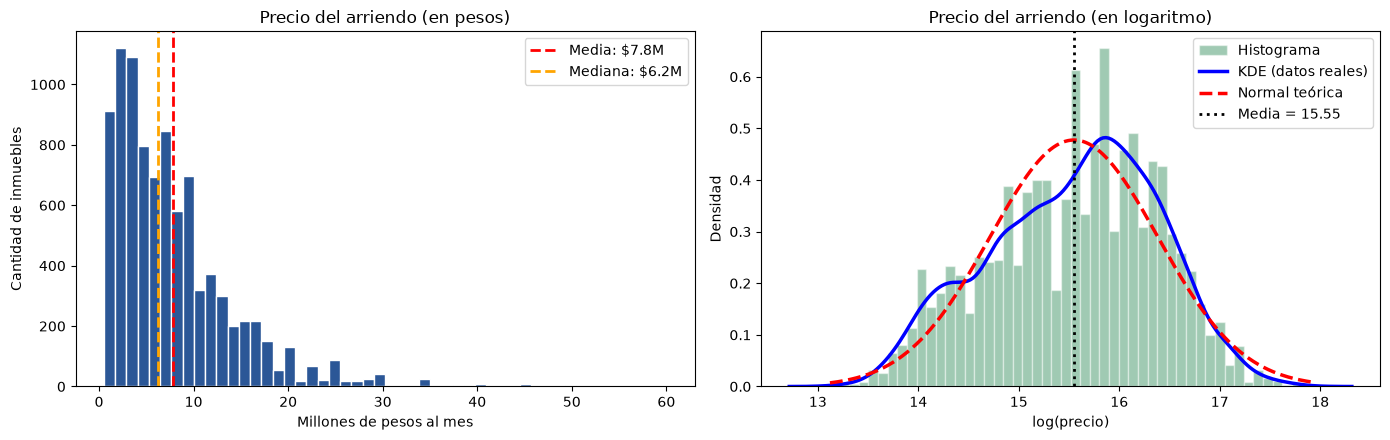

👉 Asimetría (skewness) del Precio en pesos:     1.903
👉 Asimetría del Precio en logaritmo:            -0.233


In [73]:
# ---------- G1: HISTOGRAMA DEL PRECIO, EN PESOS Y EN LOGARITMO ----------
fig, ejes = plt.subplots(1, 2, figsize=(14, 4.5))                  # subplots(1,2) crea una figura con dos gráficas lado a lado para comparar

ejes[0].hist(base['Precio'] / 1e6, bins=50, color='#2b5797', edgecolor='white')   # hist dibuja el histograma; divido entre 1e6 para leer en millones
ejes[0].axvline(base['Precio'].mean()/1e6, color='red', ls='--', lw=2, label=f"Media: ${base['Precio'].mean()/1e6:.1f}M")      # axvline traza una línea vertical en la media
ejes[0].axvline(base['Precio'].median()/1e6, color='orange', ls='--', lw=2, label=f"Mediana: ${base['Precio'].median()/1e6:.1f}M")  # otra línea en la mediana
ejes[0].set_title('Precio del arriendo (en pesos)')                # título de la gráfica izquierda
ejes[0].set_xlabel('Millones de pesos al mes')                     # qué dice el eje horizontal
ejes[0].set_ylabel('Cantidad de inmuebles')                        # qué dice el eje vertical
ejes[0].legend()                                                   # legend() muestra el cuadrito con las etiquetas de las dos líneas

# Transformación logarítmica
log_precio = np.log(base['Precio'])

# Histograma
ejes[1].hist(
    log_precio,
    bins=50,
    density=True,
    color='#2e8b57',
    edgecolor='white',
    alpha=0.45,
    label='Histograma'
)

# KDE (curva real de los datos)
sns.kdeplot(
    log_precio,
    ax=ejes[1],
    color='blue',
    linewidth=2.5,
    label='KDE (datos reales)'
)

# Campana normal teórica
mu = log_precio.mean()
sigma = log_precio.std()

x = np.linspace(log_precio.min(), log_precio.max(), 500)
y = norm.pdf(x, mu, sigma)

ejes[1].plot(
    x,
    y,
    color='red',
    linewidth=2.5,
    linestyle='--',
    label='Normal teórica'
)

# Línea de la media
ejes[1].axvline(
    mu,
    color='black',
    linestyle=':',
    linewidth=2,
    label=f'Media = {mu:.2f}'
)

ejes[1].set_title('Precio del arriendo (en logaritmo)')
ejes[1].set_xlabel('log(precio)')
ejes[1].set_ylabel('Densidad')
ejes[1].legend()


plt.tight_layout()                                                 # acomoda los márgenes para que no se pisen los textos
plt.show()                                                         # dibuja la figura en pantalla

print(f"👉 Asimetría (skewness) del Precio en pesos:     {stats.skew(base['Precio']):.3f}")     # skew mide qué tan torcida está la distribución
print(f"👉 Asimetría del Precio en logaritmo:            {stats.skew(np.log(base['Precio'])):.3f}")   # el mismo cálculo sobre el logaritmo, para comparar

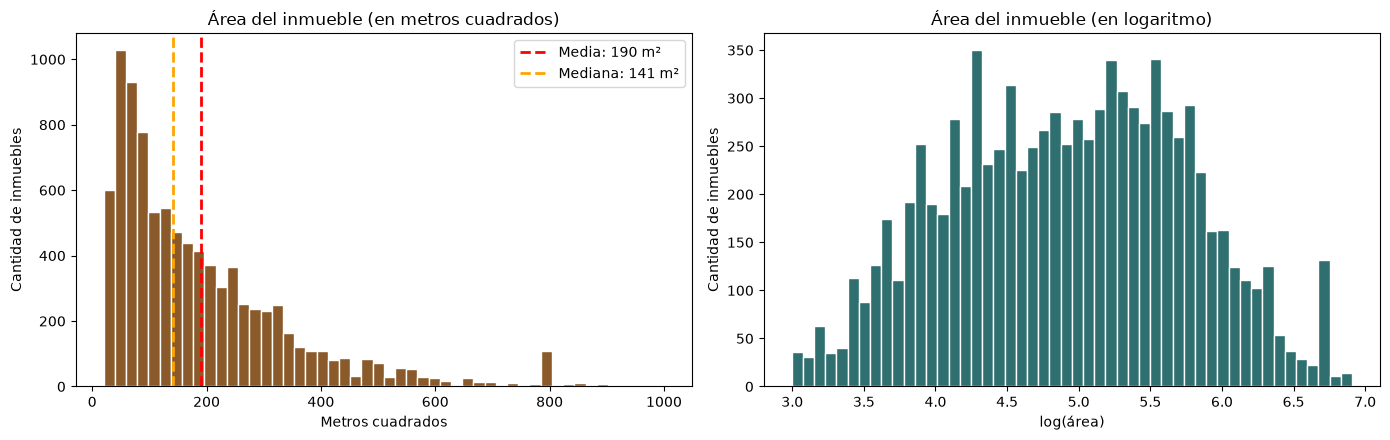

👉 Área: media = 190.0 m²  |  mediana = 141.0 m²
👉 Asimetría (skewness) del área en metros:   1.764
👉 Asimetría del área en logaritmo:           -0.031
👉 Mínimo = 20 m²   |   Máximo = 1000 m²


In [74]:
# ---------- G1b: HISTOGRAMA DEL ÁREA, EN METROS Y EN LOGARITMO ----------
fig, ejes = plt.subplots(1, 2, figsize=(14, 4.5))                  # la misma estructura de dos paneles que usé en G1, para poder comparar de una

ejes[0].hist(base['Area'], bins=50, color='#8b5a2b', edgecolor='white')   # hist del área tal como viene, en metros cuadrados
ejes[0].axvline(base['Area'].mean(), color='red', ls='--', lw=2, label=f"Media: {base['Area'].mean():.0f} m²")        # axvline marca la media con línea roja punteada
ejes[0].axvline(base['Area'].median(), color='orange', ls='--', lw=2, label=f"Mediana: {base['Area'].median():.0f} m²")  # y otra línea naranja en la mediana
ejes[0].set_title('Área del inmueble (en metros cuadrados)')       # título del panel izquierdo
ejes[0].set_xlabel('Metros cuadrados')                             # qué mide el eje horizontal
ejes[0].set_ylabel('Cantidad de inmuebles')                        # qué mide el eje vertical
ejes[0].legend()                                                   # el cuadrito que explica las dos líneas

ejes[1].hist(np.log(base['Area']), bins=50, color='#2f6f6f', edgecolor='white')   # np.log convierte cada área a su logaritmo natural
ejes[1].set_title('Área del inmueble (en logaritmo)')              # título del panel derecho
ejes[1].set_xlabel('log(área)')                                    # el eje ya no está en metros sino en logaritmos
ejes[1].set_ylabel('Cantidad de inmuebles')                        # mismo eje vertical que el panel izquierdo

plt.tight_layout()                                                 # acomoda los márgenes para que los títulos no se pisen
plt.show()                                                         # dibuja la figura

print(f"👉 Área: media = {base['Area'].mean():.1f} m²  |  mediana = {base['Area'].median():.1f} m²")   # media y mediana juntas: si la media es mayor, la distribución está jalada a la derecha
print(f"👉 Asimetría (skewness) del área en metros:   {stats.skew(base['Area']):.3f}")     # skew mide qué tan torcida está; 0 sería perfectamente simétrica
print(f"👉 Asimetría del área en logaritmo:           {stats.skew(np.log(base['Area'])):.3f}")   # el mismo cálculo sobre el log, para ver cuánto mejora
print(f"👉 Mínimo = {base['Area'].min():.0f} m²   |   Máximo = {base['Area'].max():.0f} m²")     # los extremos, para confirmar que la limpieza dejó valores razonables

In [88]:
# creamos la columna calidad
base['nivel_socioeconomico'] = 'bajo'
# creamos una máscara para los vinos de alta calidad
mask = base['estrato'] >= 5
# asignamos la calidad alta a los vinos de alta calidad
base.loc[mask, 'nivel_socioeconomico'] = 'alto'
# creamos una máscara para los vinos de baja calidad
mask = (base['estrato'] >2) & (base['estrato'] < 5)
# asignamos la calidad baja a los vinos de baja calidad
base.loc[mask, 'nivel_socioeconomico'] = 'medio'

mask = base['estrato'] <= 2 
# asignamos la calidad baja a los vinos de baja calidad
base.loc[mask, 'nivel_socioeconomico'] = 'bajo'

In [89]:
base

,Precio,Area,Area_Const,Habitaciones,Banos,Garages,Admin,estrato,antiguedad,Zona,lon,lat,Precio_por_mt2,nivel_socioeconomico
0,2700000,67.33,67.33,3.0,2.0,1.0,298200.0,4,Entre 0 y 5 años,Occidental,-74.124664,4.656461,40100.995099,medio
1,5710000,235.00,235.00,4.0,5.0,3.0,790000.0,6,Entre 5 y 10 años,Guaymaral,-74.059170,4.795217,24297.872340,alto
2,2650000,120.00,120.00,5.0,2.0,2.0,NaN,3,Más de 20 años,Occidental,-74.090000,4.689000,22083.333333,medio
3,10000000,420.00,420.00,4.0,5.0,4.0,960000.0,5,Entre 10 y 20 años,Noroccidente,-74.059950,4.763854,23809.523810,alto
4,20000000,320.00,320.00,3.0,5.0,3.0,3750000.0,6,Entre 10 y 20 años,Norte,-74.047290,4.660591,62500.000000,alto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,854000,45.00,45.00,2.0,1.0,0.0,146000.0,2,Entre 0 y 5 años,Occidental,-74.136780,4.718184,18977.777778,bajo
9997,1050000,50.00,53.00,3.0,2.0,0.0,150000.0,2,Entre 5 y 10 años,Occidental,-74.165410,4.680078,21000.000000,bajo
9998,1200000,29.00,35.00,1.0,1.0,1.0,243000.0,3,Entre 0 y 5 años,Norte,-74.028430,4.747875,41379.310345,medio
9999,3900000,80.00,80.00,2.0,2.0,2.0,0.0,6,Entre 5 y 10 años,Norte,-74.031380,4.706044,48750.000000,alto


C:\Users\victor.novoa\AppData\Local\Temp\ipykernel_22840\736726145.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=base, x='estrato', y='Precio', palette='Blues', width=0.6)


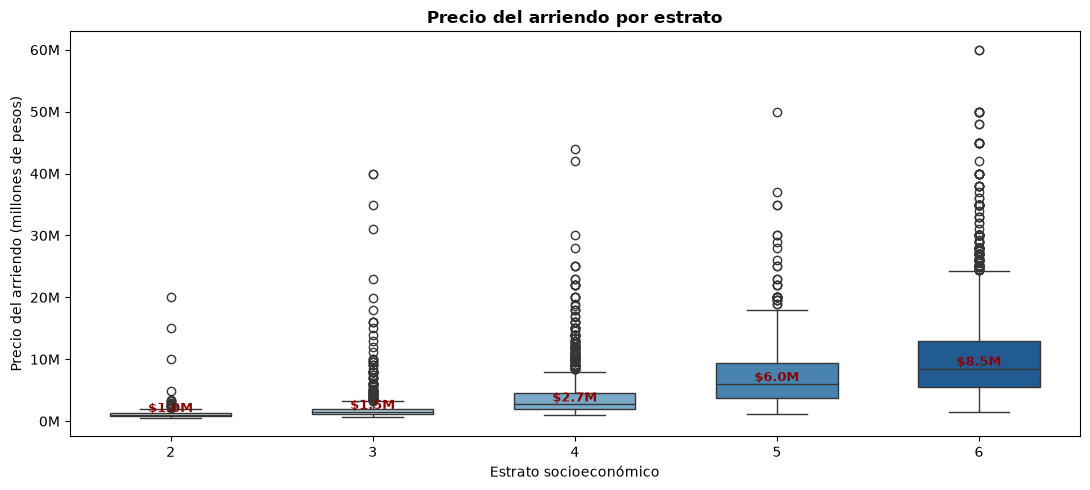

In [91]:

plt.figure(figsize=(11, 5))                                       
sns.boxplot(data=base, x='estrato', y='Precio', palette='Blues', width=0.6)  

plt.title('Precio del arriendo por estrato', fontweight='bold')   
plt.xlabel('Estrato socioeconómico')                              
plt.ylabel('Precio del arriendo (millones de pesos)')              
plt.gca().yaxis.set_major_formatter(lambda v, p: f'{v/1e6:.0f}M')  

medianas = base.groupby('estrato')['Precio'].median()            
for i, (e, m) in enumerate(medianas.items()):                      
    plt.text(i, m, f'${m/1e6:.1f}M', ha='center', va='bottom',    
             fontweight='bold', fontsize=9, color='darkred')       

plt.tight_layout()                                                
plt.show()                                                       
 

<Axes: xlabel='nivel_socioeconomico', ylabel='Precio'>

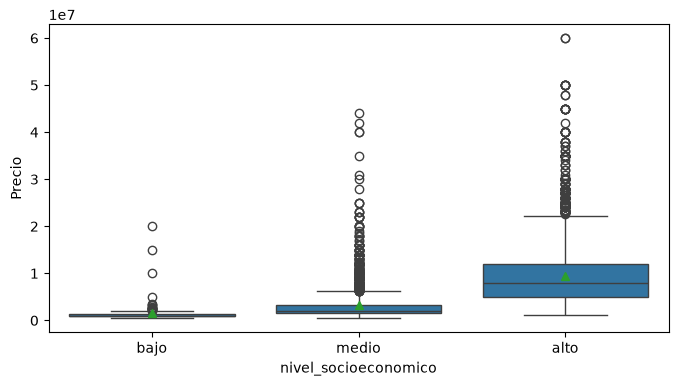

In [95]:
# graficando la distribución de densidad del vino para diferentes calidades
fig, ax = plt.subplots(figsize=(8, 4))
# fijando un orden para las calidades
order = ['bajo', 'medio', 'alto']
# usamos un boxplot de seaborn para crear la visualización
sns.boxplot(data = base, x='nivel_socioeconomico', y = 'Precio', order=order, showmeans=True, ax=ax)

In [96]:
# graficamos el Precio por calidad usando un boxplot en plotly
import plotly.express as px
# fijamos un orden para las estratos
order = ['bajo', 'medio', 'alto']

# graficamos el boxplot
fig = px.box(base, x='nivel_socioeconomico', y='Precio_por_mt2', points='all', title='Precio por estrato', category_orders={'nivel_socioeconomico': order})
fig.update_traces(marker=dict(size=5))
fig.update_layout(title_x=0.5)
fig.show()

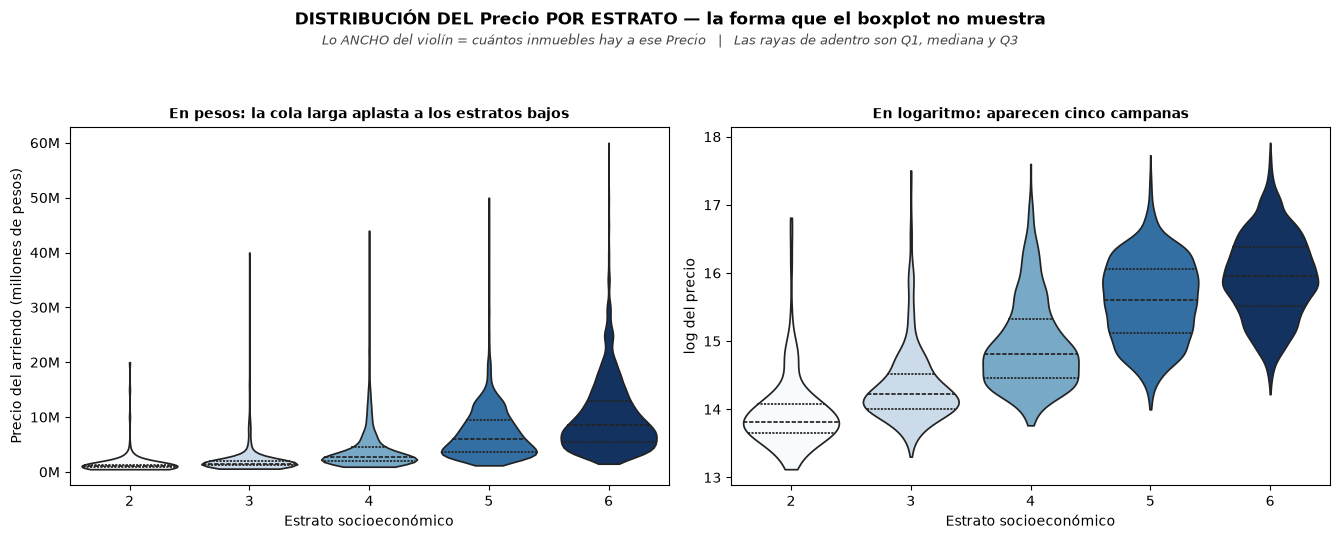

👉 Asimetría (skew) del precio dentro de cada estrato:
         Skew en pesos  Skew en log
estrato                            
2                6.620        2.431
3                7.596        2.038
4                3.693        0.956
5                2.097        0.021
6                1.825        0.037

✅ En pesos, TODOS los estratos dan asimetría positiva y alta: la cola larga va hacia
   la derecha, o sea que en cada estrato hay unos pocos arriendos mucho más caros.
✅ En logaritmo la asimetría baja muchísimo y los violines se vuelven campanas.
   Esa es, en una sola imagen, la razón de usar el logaritmo en las partes 5, 6 y 7.
✅ Ningún estrato muestra dos bultos separados, así que cada uno es un solo mercado
   y no dos mezclados bajo la misma etiqueta. Eso habilita el ANOVA de la Parte 6.


In [92]:
# ---------- G2b: VIOLÍN DEL PRECIO POR ESTRATO (la gráfica del Caso 4) ----------
base_v = base.copy()                                              
base_v['log_precio_tmp'] = np.log(base_v['Precio'])              

fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.4))                 
fig.suptitle('DISTRIBUCIÓN DEL Precio POR ESTRATO — la forma que el boxplot no muestra', 
             fontsize=12.5, fontweight='bold', y=0.99)           
fig.text(0.5, 0.925,                                              
         'Lo ANCHO del violín = cuántos inmuebles hay a ese Precio   |   '  
         'Las rayas de adentro son Q1, mediana y Q3',             
         ha='center', fontsize=9.5, style='italic', color='#444') 

sns.violinplot(data=base_v, x='estrato', y='Precio', ax=ax[0],    
               hue='estrato', palette='Blues', legend=False,      
               inner='quartile', cut=0)                           
ax[0].set_title('En pesos: la cola larga aplasta a los estratos bajos', fontweight='bold', fontsize=10)   
ax[0].set_xlabel('Estrato socioeconómico')                        
ax[0].set_ylabel('Precio del arriendo (millones de pesos)')        
ax[0].yaxis.set_major_formatter(lambda v, p: f'{v/1e6:.0f}M')      

sns.violinplot(data=base_v, x='estrato', y='log_precio_tmp', ax=ax[1],  
               hue='estrato', palette='Blues', legend=False,      
               inner='quartile', cut=0)                           
ax[1].set_title('En logaritmo: aparecen cinco campanas', fontweight='bold', fontsize=10)  
ax[1].set_xlabel('Estrato socioeconómico')                        
ax[1].set_ylabel('log del precio')                                

plt.tight_layout(rect=[0, 0, 1, 0.90])                            
plt.show()                                                        

print("👉 Asimetría (skew) del precio dentro de cada estrato:")    
comp = pd.DataFrame({                                             
    'Skew en pesos': base_v.groupby('estrato')['Precio'].skew(),   
    'Skew en log':   base_v.groupby('estrato')['log_precio_tmp'].skew(),  
}).round(3)
print(comp.to_string())                                           

print("\n✅ En pesos, TODOS los estratos dan asimetría positiva y alta: la cola larga va hacia")   
print("   la derecha, o sea que en cada estrato hay unos pocos arriendos mucho más caros.")       
print("✅ En logaritmo la asimetría baja muchísimo y los violines se vuelven campanas.")          
print("   Esa es, en una sola imagen, la razón de usar el logaritmo en las partes 5, 6 y 7.")      
print("✅ Ningún estrato muestra dos bultos separados, así que cada uno es un solo mercado")       
print("   y no dos mezclados bajo la misma etiqueta. Eso habilita el ANOVA de la Parte 6.")       

C:\Users\victor.novoa\AppData\Local\Temp\ipykernel_22840\826804320.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=base, x='Zona', y='Precio', order=orden_zonas, palette='YlOrRd_r', width=0.6)


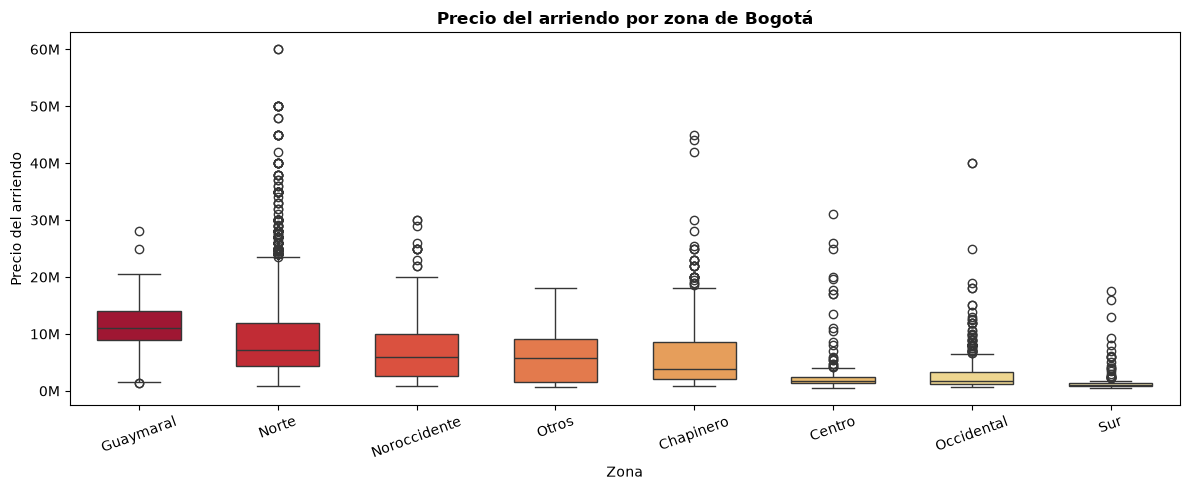

👉 Mediana por zona:
Zona
Guaymaral       11.06
Norte            7.20
Noroccidente     6.00
Otros            5.85
Chapinero        3.85
Centro           1.80
Occidental       1.80
Sur              1.10


In [97]:
# ---------- G3: BOXPLOT DEL PRECIO POR ZONA ----------
orden_zonas = base.groupby('Zona')['Precio'].median().sort_values(ascending=False).index  

plt.figure(figsize=(12, 5))                                        
sns.boxplot(data=base, x='Zona', y='Precio', order=orden_zonas, palette='YlOrRd_r', width=0.6) 

plt.title('Precio del arriendo por zona de Bogotá', fontweight='bold')   
plt.xlabel('Zona')                                               
plt.ylabel('Precio del arriendo')                                  
plt.gca().yaxis.set_major_formatter(lambda v, p: f'{v/1e6:.0f}M') 
plt.xticks(rotation=20)                                           

plt.tight_layout()                                                
plt.show()                                                         

print("👉 Mediana por zona:")                                      
print((base.groupby('Zona')['Precio'].median().sort_values(ascending=False) / 1e6).round(2).to_string())  

C:\Users\victor.novoa\AppData\Local\Temp\ipykernel_22840\2432234620.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=base, x='antiguedad', y='Precio', order=orden_ant, palette='Greens', width=0.6)


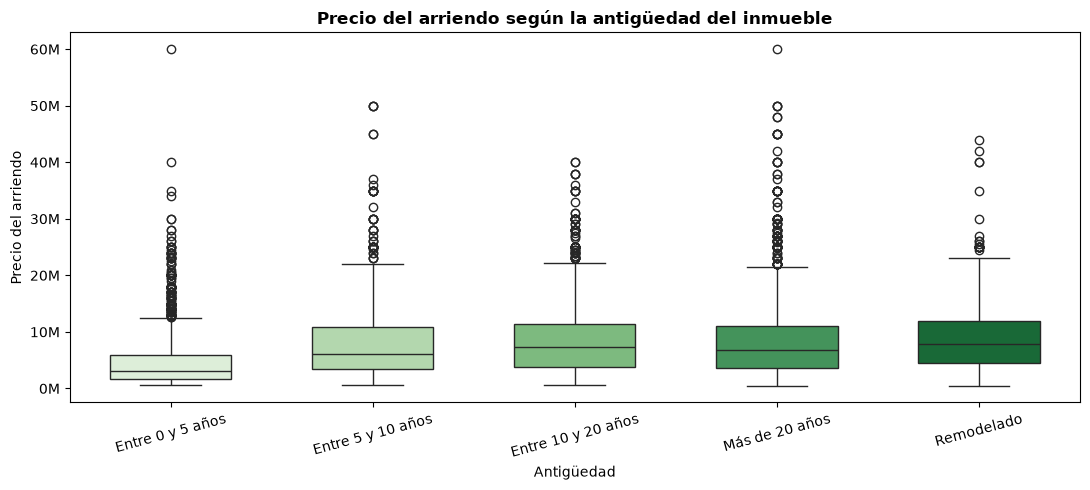

In [98]:
# ---------- G4: BOXPLOT DEL PRECIO POR ANTIGÜEDAD ----------
orden_ant = ['Entre 0 y 5 años', 'Entre 5 y 10 años',            
             'Entre 10 y 20 años', 'Más de 20 años', 'Remodelado'] 

plt.figure(figsize=(11, 5))                                        
sns.boxplot(data=base, x='antiguedad', y='Precio', order=orden_ant, palette='Greens', width=0.6)   

plt.title('Precio del arriendo según la antigüedad del inmueble', fontweight='bold')  
plt.xlabel('Antigüedad')                                          
plt.ylabel('Precio del arriendo')                                 
plt.gca().yaxis.set_major_formatter(lambda v, p: f'{v/1e6:.0f}M')  
plt.xticks(rotation=15)                                           

plt.tight_layout()                                                
plt.show()                                                       
 

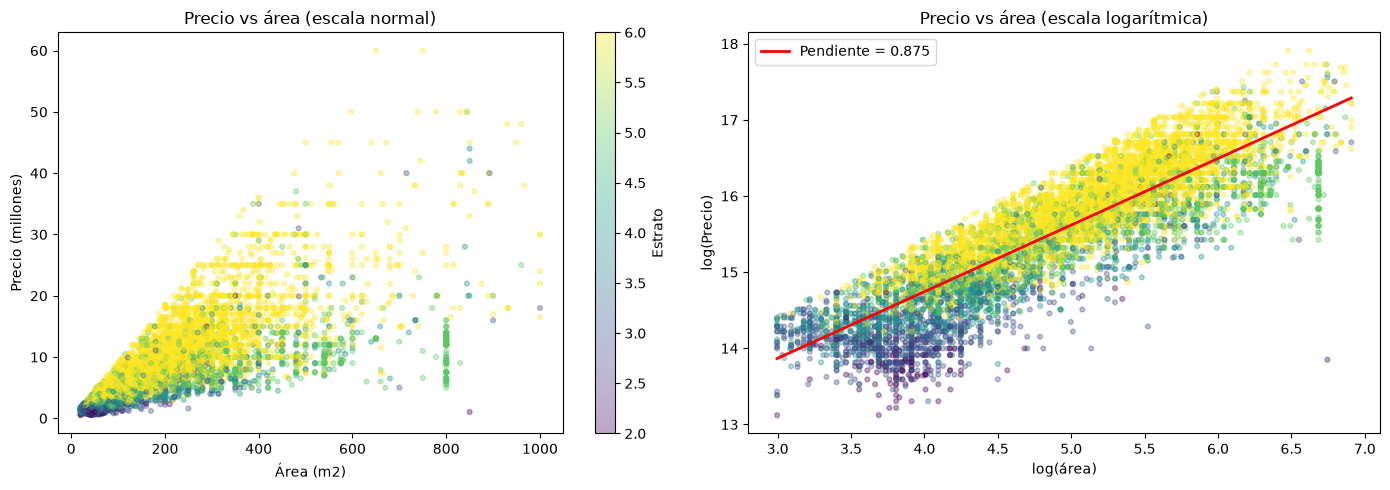

👉 Correlación área-Precio (escala normal):     0.7385
👉 Correlación log(área)-log(Precio):           0.8663


In [99]:
# ---------- G5: DISPERSIÓN PRECIO vs ÁREA, EN ESCALA NORMAL Y EN LOGARITMO ----------
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))                    # dos gráficas lado a lado: la misma relación en dos escalas

sc = ejes[0].scatter(base['Area'], base['Precio'] / 1e6,           # scatter dibuja un punto por inmueble: área en X, Precio en Y
                     c=base['estrato'], cmap='viridis',            # c= pinta cada punto según el estrato; cmap es la paleta de colores
                     alpha=0.35, s=12)                             # alpha=0.35 los hace semitransparentes: donde hay muchos se ve más oscuro
ejes[0].set_title('Precio vs área (escala normal)')                # título de la izquierda
ejes[0].set_xlabel('Área (m2)')                                    # eje X en metros cuadrados
ejes[0].set_ylabel('Precio (millones)')                            # eje Y en millones
plt.colorbar(sc, ax=ejes[0], label='Estrato')                      # colorbar agrega la barra que explica qué color es qué estrato

ejes[1].scatter(np.log(base['Area']), np.log(base['Precio']),      # la misma nube pero con logaritmo en los dos ejes
                c=base['estrato'], cmap='viridis', alpha=0.35, s=12)   # mismos colores por estrato para poder comparar
coef = np.polyfit(np.log(base['Area']), np.log(base['Precio']), 1) # polyfit ajusta una recta y devuelve [pendiente, intercepto]
xx = np.linspace(np.log(base['Area']).min(), np.log(base['Area']).max(), 100)   # linspace crea 100 puntos parejos para dibujar la recta
ejes[1].plot(xx, coef[0] * xx + coef[1], 'r-', lw=2,               # plot dibuja la recta de tendencia encima de la nube
             label=f'Pendiente = {coef[0]:.3f}')                   # la pendiente es la elasticidad, que explico abajo
ejes[1].set_title('Precio vs área (escala logarítmica)')           # título de la derecha
ejes[1].set_xlabel('log(área)')                                    # eje X en logaritmo
ejes[1].set_ylabel('log(Precio)')                                  # eje Y en logaritmo
ejes[1].legend()                                                   # muestro la etiqueta de la pendiente

plt.tight_layout()                                                 # márgenes
plt.show()                                                         # dibujo

print(f"👉 Correlación área-Precio (escala normal):     {base['Area'].corr(base['Precio']):.4f}")   # corr de Pearson en pesos y m2
print(f"👉 Correlación log(área)-log(Precio):           {np.log(base['Area']).corr(np.log(base['Precio'])):.4f}")   # la misma correlación en logaritmos
 

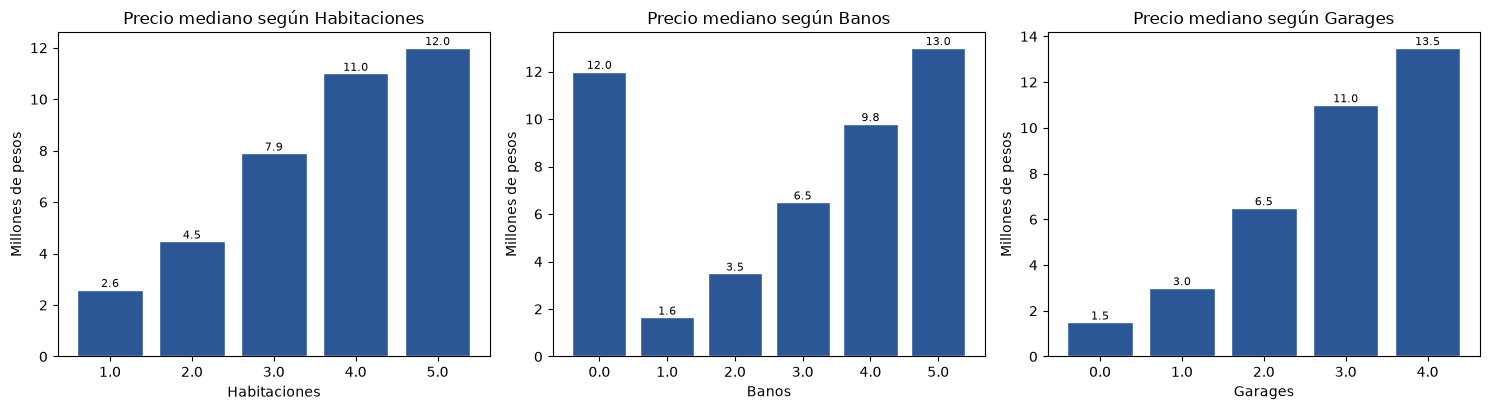

In [ ]:
fig, ejes = plt.subplots(1, 3, figsize=(15, 4.2))                  # tres gráficas en una fila, una por variable
 
for i, var in enumerate(['Habitaciones', 'Banos', 'Garages']):     # recorro las tres variables; enumerate me da la posición para saber en qué eje va
    t = base.groupby(var)['Precio'].median() / 1e6                 # mediana del precio para cada valor de la variable, en millones
    ejes[i].bar(t.index.astype(str), t.values, color='#2b5797', edgecolor='white')   # bar dibuja las barras; astype(str) evita que el eje X quede con decimales
    ejes[i].set_title(f'Precio mediano según {var}')               # título de cada subgráfica
    ejes[i].set_xlabel(var)                                        # eje X con el nombre de la variable
    ejes[i].set_ylabel('Millones de pesos')                        # eje Y en millones
    for j, v in enumerate(t.values):                               # recorro las barras para escribirles el valor encima
        ejes[i].text(j, v, f'{v:.1f}', ha='center', va='bottom', fontsize=8)   # el número exacto sobre cada barra
 
plt.tight_layout()                                                 # márgenes
plt.show()    

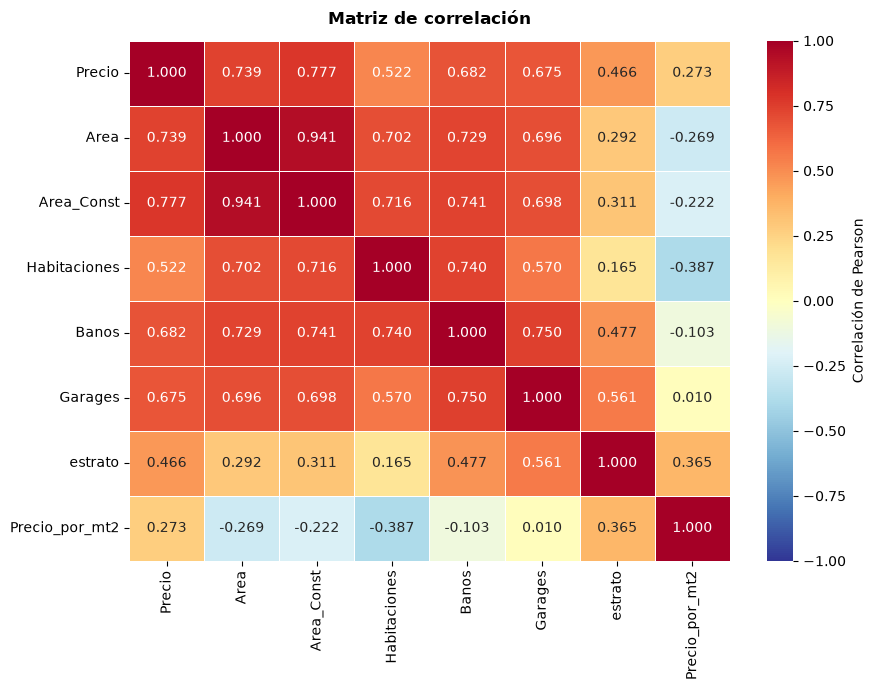

👉 Correlación de cada variable con el Precio, de mayor a menor:
Area_Const        0.7768
Area              0.7385
Banos             0.6820
Garages           0.6751
Habitaciones      0.5221
estrato           0.4663
Precio_por_mt2    0.2727


In [107]:
numericas = base[['Precio', 'Area', 'Area_Const', 'Habitaciones',  # escojo las variables numéricas relevantes
                  'Banos', 'Garages', 'estrato', 'Precio_por_mt2']]     # incluyo Precio_m2 aunque sea derivada, para ver cómo se relaciona
matriz = numericas.corr()                                          # corr() calcula la correlación de Pearson entre todos los pares
 
plt.figure(figsize=(9, 7))                                         # figura cuadrada, que es como mejor se ve un mapa de calor
sns.heatmap(matriz, annot=True, fmt='.3f', cmap='RdYlBu_r',        # heatmap pinta la matriz; annot=True escribe el número dentro de cada casilla
            center=0, vmin=-1, vmax=1, linewidths=0.5,             # center=0 hace que el blanco sea correlación cero: positivas rojas, negativas azules
            cbar_kws={'label': 'Correlación de Pearson'})          # etiqueta de la barra de color
 
plt.title('Matriz de correlación', fontweight='bold', pad=12)      # título con un poco de espacio arriba
plt.tight_layout()                                                 # márgenes
plt.show()                                                         # dibujo
 
print("👉 Correlación de cada variable con el Precio, de mayor a menor:")   # el resumen que de verdad interesa
print(matriz['Precio'].drop('Precio').sort_values(ascending=False).round(4).to_string())   # drop('precio') quita el 1.0 de la variable consigo misma

C:\Users\victor.novoa\AppData\Local\Temp\ipykernel_22840\3461602360.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=base, x='Zona', y='Precio_por_mt2', order=orden_m2, palette='PuBu_r', width=0.6)   # boxplot del precio por m2


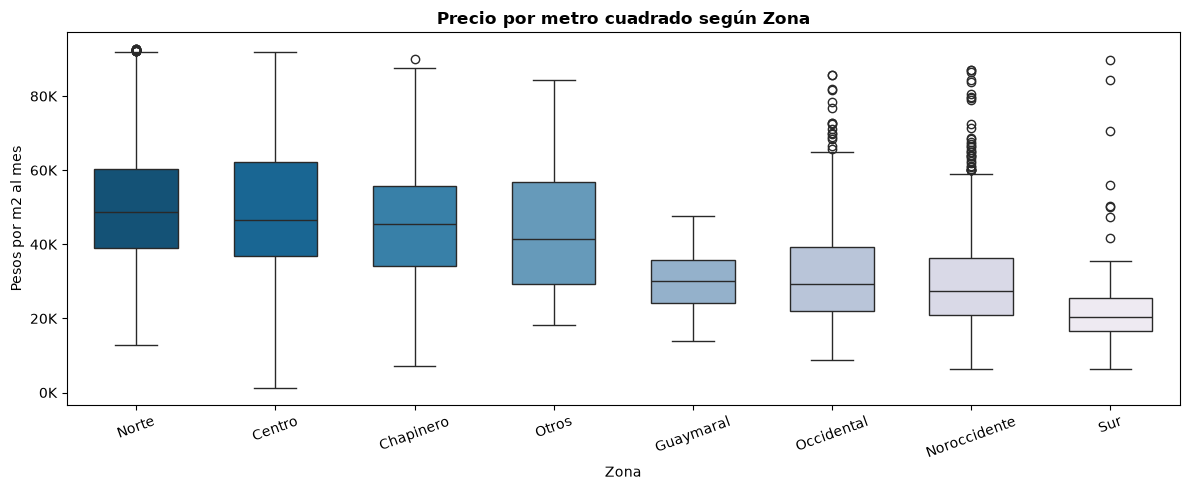

👉 Comparación: precio total vs tamaño vs precio por m2
              precio_mediano  m2_mediano  precio_m2_mediano
Zona                                                       
Norte              7200000.0       156.0            48750.0
Centro             1800000.0        39.0            46667.0
Chapinero          3850000.0        92.0            45473.0
Otros              5850000.0       131.0            41507.0
Guaymaral         11060000.0       380.0            30000.0
Occidental         1800000.0        62.0            29167.0
Noroccidente       6000000.0       221.0            27273.0
Sur                1100000.0        50.0            20460.0


In [108]:
# ---------- G8: BOXPLOT DEL PRECIO POR M2 SEGÚN ZONA ----------
orden_m2 = base.groupby('Zona')['Precio_por_mt2'].median().sort_values(ascending=False).index   # ordeno las Zonas por precio del m2, no por precio total

plt.figure(figsize=(12, 5))                                        # figura
sns.boxplot(data=base, x='Zona', y='Precio_por_mt2', order=orden_m2, palette='PuBu_r', width=0.6)   # boxplot del precio por m2

plt.title('Precio por metro cuadrado según Zona', fontweight='bold')   # título
plt.xlabel('Zona')                                                 # eje X
plt.ylabel('Pesos por m2 al mes')                                  # eje Y: acá la unidad ya está normalizada por tamaño
plt.gca().yaxis.set_major_formatter(lambda v, p: f'{v/1000:.0f}K') # el eje en miles ("40K") se lee mejor que 40000
plt.xticks(rotation=20)                                            # roto las etiquetas

plt.tight_layout()                                                 # márgenes
plt.show()                                                         # dibujo

comp = base.groupby('Zona').agg(                                   # tabla para comparar el ranking por precio total contra el ranking por m2
    precio_mediano=('Precio', 'median'),                           # mediana del precio total
    m2_mediano=('Area', 'median'),                                 # tamaño mediano del inmueble en esa Zona
    precio_m2_mediano=('Precio_por_mt2', 'median'),                     # mediana del precio por metro cuadrado
).round(0).sort_values('precio_m2_mediano', ascending=False)       # ordenada por precio del m2
print("👉 Comparación: precio total vs tamaño vs precio por m2")   # encabezado
print(comp.to_string())                                            # imprimo la tabla
 

👉 Inmuebles con coordenada válida: 8,997 de 9,066


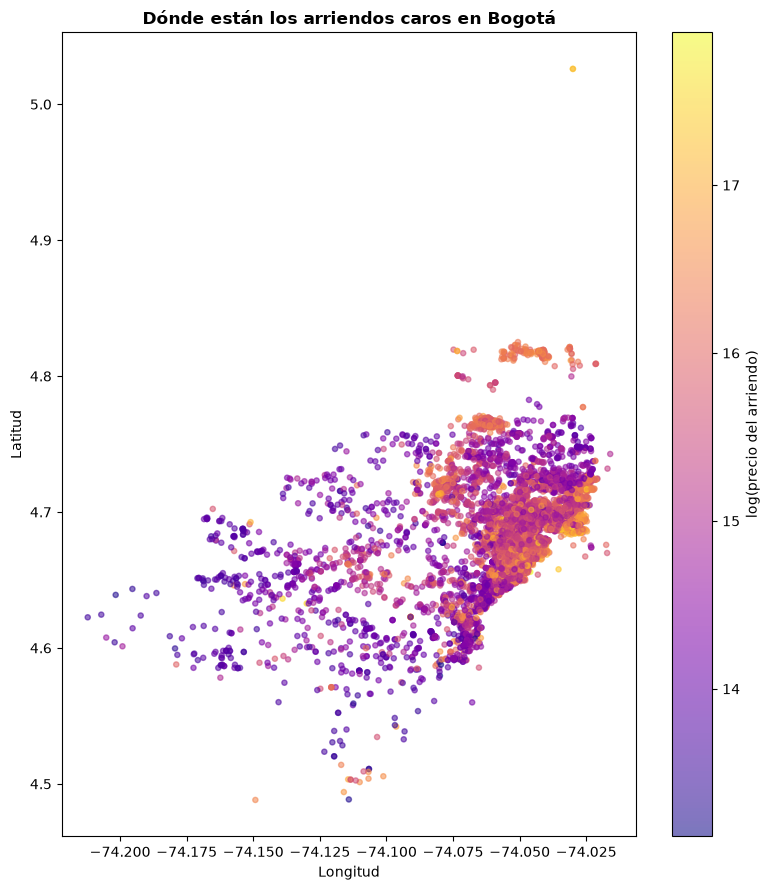

In [109]:
# ---------- G9: MAPA DE LOS INMUEBLES SEGÚN SU PRECIO ----------
con_coord = base.dropna(subset=['lon', 'lat'])                     # solo puedo mapear los que tienen coordenada válida (acuérdese que los (0,0) los volví nulos)
print(f"👉 Inmuebles con coordenada válida: {len(con_coord):,} de {len(base):,}")   # cuántos entran al mapa

plt.figure(figsize=(8, 9))                                         # figura alta porque Bogotá es más larga que ancha
sc = plt.scatter(con_coord['lon'], con_coord['lat'],               # cada punto es un inmueble en su ubicación real
                 c=np.log(con_coord['Precio']),                    # el color depende del logaritmo del precio: si usara el precio pelado, los caros taparían todo
                 cmap='plasma', alpha=0.55, s=14)                  # paleta plasma: morado = barato, amarillo = caro

plt.colorbar(sc, label='log(precio del arriendo)')                 # la barra que traduce color a precio
plt.title('Dónde están los arriendos caros en Bogotá', fontweight='bold')   # título
plt.xlabel('Longitud')                                             # eje X: coordenada este-oeste
plt.ylabel('Latitud')                                              # eje Y: coordenada norte-sur

plt.tight_layout()                                                 # márgenes
plt.show()                                                         # dibujo
 